# TOSA Adjacent Channel Spacing: Problem Statement and Strategy Comparison

*Run this notebook from the `architecture_band_muxed` folder so that the scripts and figures work correctly. Then use **File → Print → Save as PDF** (or **jupyter nbconvert --to pdf**) to export to PDF.*

This report summarizes the problem of **TOSA (Tunable Optical Sub-Assembly) yield** with respect to **adjacent channel spacing error**, and compares three assembly strategies. The goal is to maximize the fraction of TOSAs that meet a **maximum absolute spacing error** threshold (e.g. **≤ 40 GHz**).

---

## 1. Problem Statement

### 1.1 Context

- A **TOSA** contains **4 lasers**, one per channel (ch0–ch3), in a band-muxed architecture.
- Channel centers are defined in **frequency deviation** from a reference wavelength (1311 nm).
- For the **200 GHz class** (the case analyzed here), the four channel centers are:
  - **ch0:** 0 GHz  
  - **ch1:** +200 GHz  
  - **ch2:** −200 GHz  
  - **ch3:** −400 GHz  
  (all relative to the frequency at 1311 nm).

- Each laser's actual frequency varies around its channel center due to manufacturing spread. We assume a **Gaussian** distribution with **3σ = ±1 nm** in wavelength at 1311 nm, which corresponds to **σ ≈ 58.2 GHz** in frequency.

The figure below shows the laser frequency distributions for each channel under 200 GHz and 400 GHz channel spacing (centered at 1311 nm).
  - ch1 − ch0: **200 GHz**
  - ch2 − ch1: **−400 GHz**
  - ch3 − ch2: **−200 GHz**

- For a given TOSA (four laser frequencies), we compute the **three adjacent spacing errors**:
  - Spacing error (ch0–ch1) = (f₁ − f₀) − 200  
  - Spacing error (ch1–ch2) = (f₂ − f₁) − (−400)  
  - Spacing error (ch2–ch3) = (f₃ − f₂) − (−200)  

- We care about the **maximum absolute spacing error** over these three pairs **per TOSA**:
  - **Max |error| per TOSA** = max{ |e₀₁|, |e₁₂|, |e₂₃| } (in GHz).

### 1.3 Yield Metric

- A TOSA is considered **in-spec** for a threshold **T** (e.g. 40 GHz) if:
  - **Max |spacing error| ≤ T GHz.**

- **Yield** = (number of TOSAs with max |error| ≤ T) / (total number of TOSAs built), expressed as a percentage.

- The report focuses on **maximizing yield at ≤ 40 GHz** and also reports yields at 20, 100, and 200 GHz for context. At 1311 nm, **40 GHz ≈ ±0.23 nm** wavelength error.

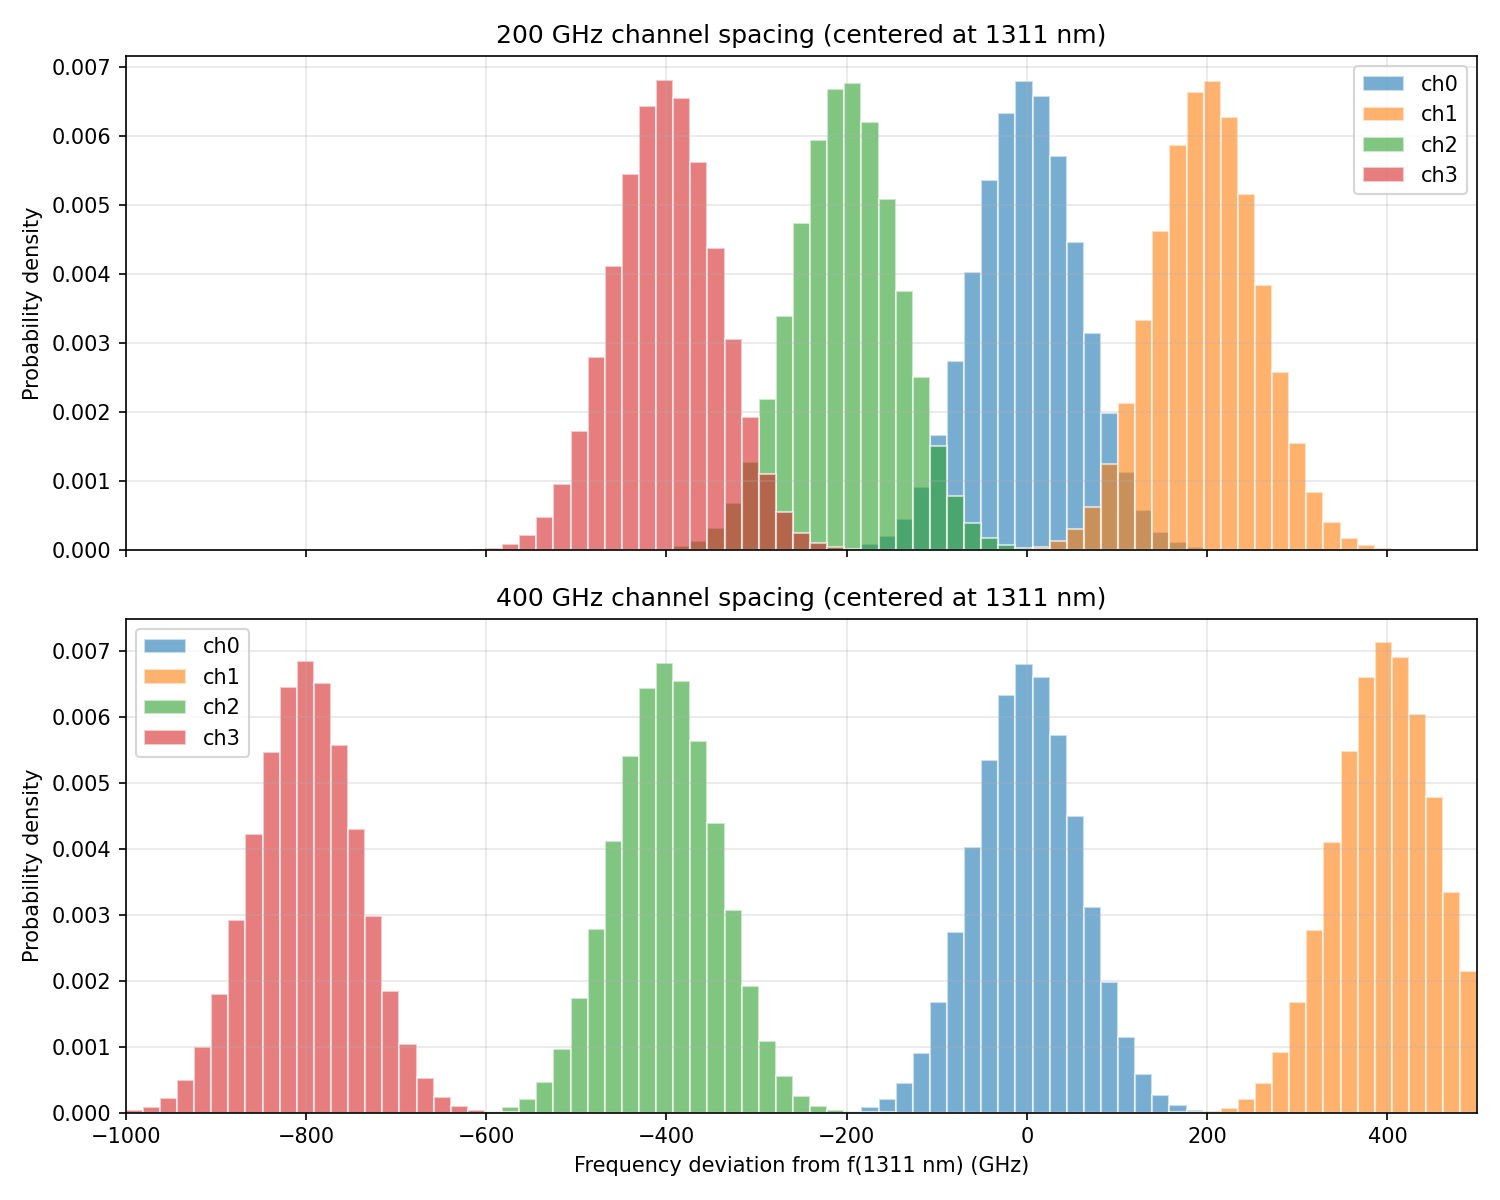

In [1]:
from IPython.display import Image, display
display(Image(filename="laser_frequency_histograms.png", width=700))

### 1.2 Adjacent Spacing Error

- **Nominal adjacent spacings** (target values) are:
  - ch1 − ch0: **200 GHz**
  - ch2 − ch1: **−400 GHz**
  - ch3 − ch2: **−200 GHz**

- For a given TOSA (four laser frequencies), we compute the **three adjacent spacing errors**:
  - Spacing error (ch0–ch1) = (f₁ − f₀) − 200  
  - Spacing error (ch1–ch2) = (f₂ − f₁) − (−400)  
  - Spacing error (ch2–ch3) = (f₃ − f₂) − (−200)  

- We care about the **maximum absolute spacing error** over these three pairs **per TOSA**:
  - **Max |error| per TOSA** = max{ |e₀₁|, |e₁₂|, |e₂₃| } (in GHz).

### 1.3 Yield Metric

- A TOSA is considered **in-spec** for a threshold **T** (e.g. 40 GHz) if:
  - **Max |spacing error| ≤ T GHz.**

- **Yield** = (number of TOSAs with max |error| ≤ T) / (total number of TOSAs built), expressed as a percentage.

- The report focuses on **maximizing yield at ≤ 40 GHz** and also reports yields at 20, 100, and 200 GHz for context. At 1311 nm, **40 GHz ≈ ±0.23 nm** wavelength error.

---

## 2. Strategies Compared

Three strategies are implemented. All use the same channel grid and laser statistics (Gaussian, 3σ = ±1 nm at 1311 nm).

### 2.1 Random Sampling

- **Method:** For each TOSA, **randomly** pick one laser from each channel (independent Gaussian samples around each channel center). No binning or matching across channels.
- **Sample size (this report):** 10 M TOSAs (200 GHz class), seed 42.

### 2.2 Binned Sampling — 4-Bin Scheme

- **Method:** Sample a **full inventory** of **10 M lasers per channel**. Assign each laser to one of **4 bins** by its **deviation from target** (GHz): **BIN0** (−1000 to −100), **BIN1** (−100 to 0), **BIN2** (0 to 100), **BIN3** (100 to 1000). Build TOSAs by selecting **one laser per channel from the same bin index**. No per-bin cap; total TOSAs ≈ 10 M.

### 2.3 Binned Sampling — 10-Bin Scheme

- **Method:** Same idea as 4-bin, but with **10 bins** of **40 GHz width**: **BIN0** (−1000 to −160), **BIN1** (−160 to −120), …, **BIN9** (160 to 200 GHz). Full inventory per bin (no cap). Total TOSAs ≈ 10 M.

### 2.4 Bin definitions (4-bin and 10-bin)

The figure below shows how the **4-bin** and **10-bin** schemes partition laser **deviation from target** (GHz). The gray curve is the laser deviation PDF (Gaussian, σ ≈ 58.2 GHz). Colored vertical bands are the bins; TOSAs are built by picking one laser per channel from the same bin.

Saved bin_definition_histogram.png


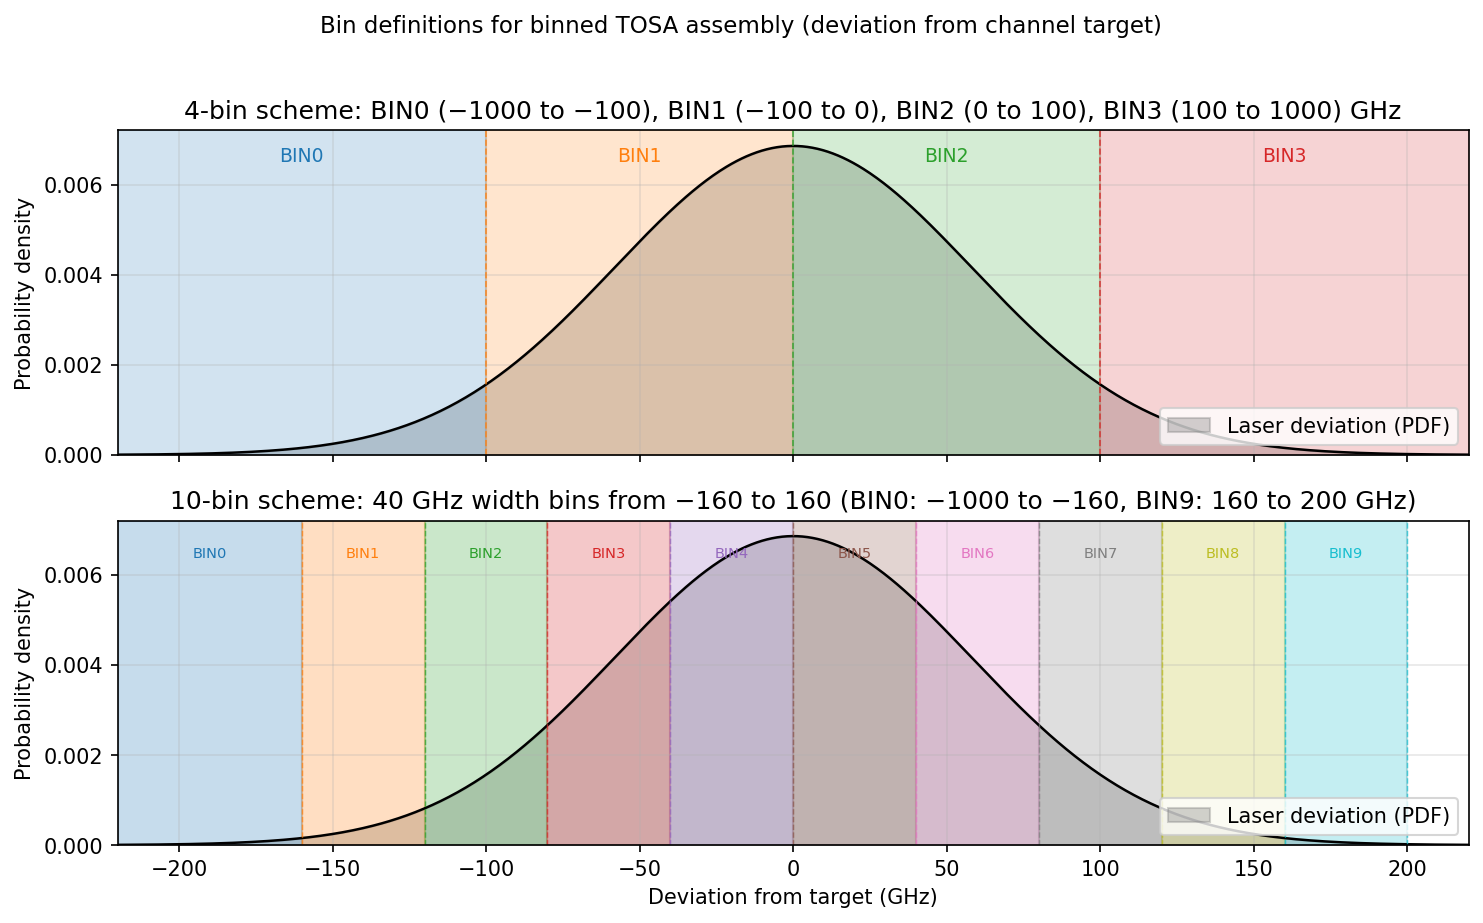

In [2]:
# Generate bin definition figure and display inline
import bin_definition_histogram as bd
bd.plot_bin_definition_histogram(out_path="bin_definition_histogram.png")

from IPython.display import Image, display
display(Image(filename="bin_definition_histogram.png", width=700))

---

## 3. Yield Comparison (Seed 42)

Numerical results (200 GHz class only). All three strategies use comparable sample sizes (~10 M TOSAs). Binned sampling uses a **full inventory** of **10 M lasers per channel** with **no per-bin cap**.

In [3]:
# Run analyses and generate yield table + figures
import numpy as np
import random_sampling_tosa as r
import binned_sampling_tosa as b

np.random.seed(42)
tosas_200 = r.build_tosas_for_class(r.CHANNELS_200_GHZ, r.N_TOSAS_PER_CLASS)
errors_r = np.diff(tosas_200, axis=1) - r.NOMINAL_SPACING_200
max_r = np.max(np.abs(errors_r), axis=1)
n_r = len(max_r)

rng = np.random.default_rng(42)
e10, e4 = b.run_binned_sampling_200ghz(rng)
max_4 = np.max(np.abs(e4), axis=1)
max_10 = np.max(np.abs(e10), axis=1)
n_4, n_10 = len(max_4), len(max_10)

thresholds_ghz = [20, 40, 100, 200]
pct_r = [100 * np.sum(max_r <= t) / n_r for t in thresholds_ghz]
pct_4 = [100 * np.sum(max_4 <= t) / n_4 for t in thresholds_ghz]
pct_10 = [100 * np.sum(max_10 <= t) / n_10 for t in thresholds_ghz]
wl_nm = [r.ghz_to_wavelength_error_nm(t) for t in thresholds_ghz]

print('Max |error|     | Random (%) | 4-bin (%) | 10-bin (%) | Wavelength error (nm)')
print('-' * 72)
for t, pr, p4, p10, w in zip(thresholds_ghz, pct_r, pct_4, pct_10, wl_nm):
    print(f'  ≤ {t:3} GHz     | {pr:9.2f} | {p4:8.2f} | {p10:9.2f} | ±{w:.3f}')
print(f'\nTOSA counts: Random {n_r:,}  |  4-bin {n_4:,}  |  10-bin {n_10:,}')

# Generate figures
r.plot_adjacent_spacing_error_histograms(tosas_200, out_path="random_sampling_tosa_adjacent_spacing_error_histograms.png")
b.plot_binned_spacing_error_histograms(e10, e4, out_path="binned_sampling_tosa_spacing_error_histograms.png")

Max |error|     | Random (%) | 4-bin (%) | 10-bin (%) | Wavelength error (nm)
------------------------------------------------------------------------
  ≤  20 GHz     |      0.99 |     9.37 |     47.48 | ±0.115
  ≤  40 GHz     |      6.85 |    40.30 |     99.88 | ±0.229
  ≤ 100 GHz     |     51.36 |    99.89 |    100.00 | ±0.573
  ≤ 200 GHz     |     95.86 |   100.00 |    100.00 | ±1.147

TOSA counts: Random 10,000,000  |  4-bin 9,995,164  |  10-bin 9,993,758
Saved random_sampling_tosa_adjacent_spacing_error_histograms.png
Saved binned_sampling_tosa_spacing_error_histograms.png


**Random sampling — adjacent spacing error histograms and yield table:**

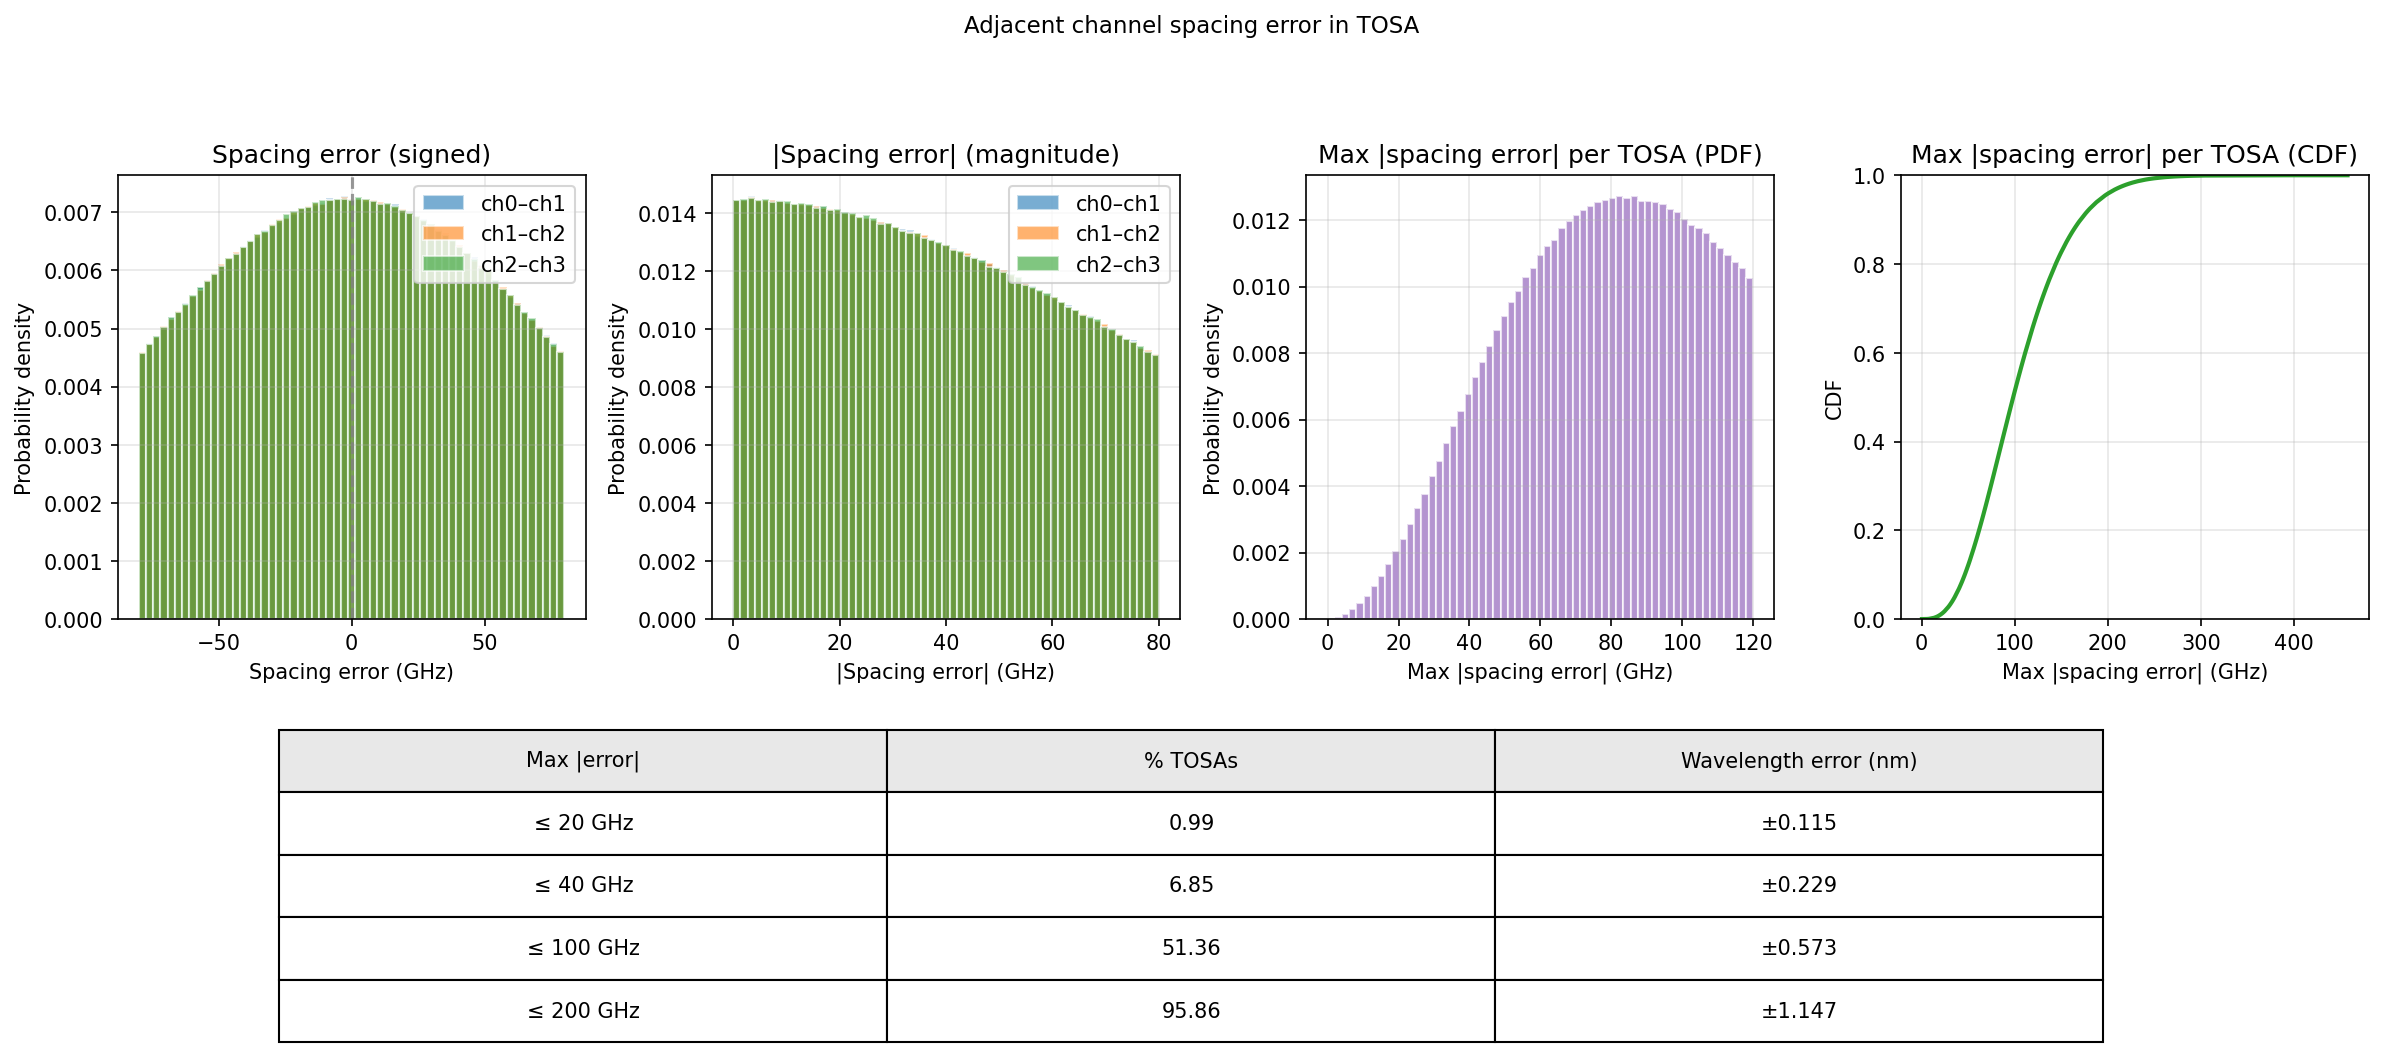

In [4]:
from IPython.display import Image, display
display(Image(filename="random_sampling_tosa_adjacent_spacing_error_histograms.png", width=800))

**Binned sampling (4-bin and 10-bin) — adjacent spacing error histograms and yield table:**

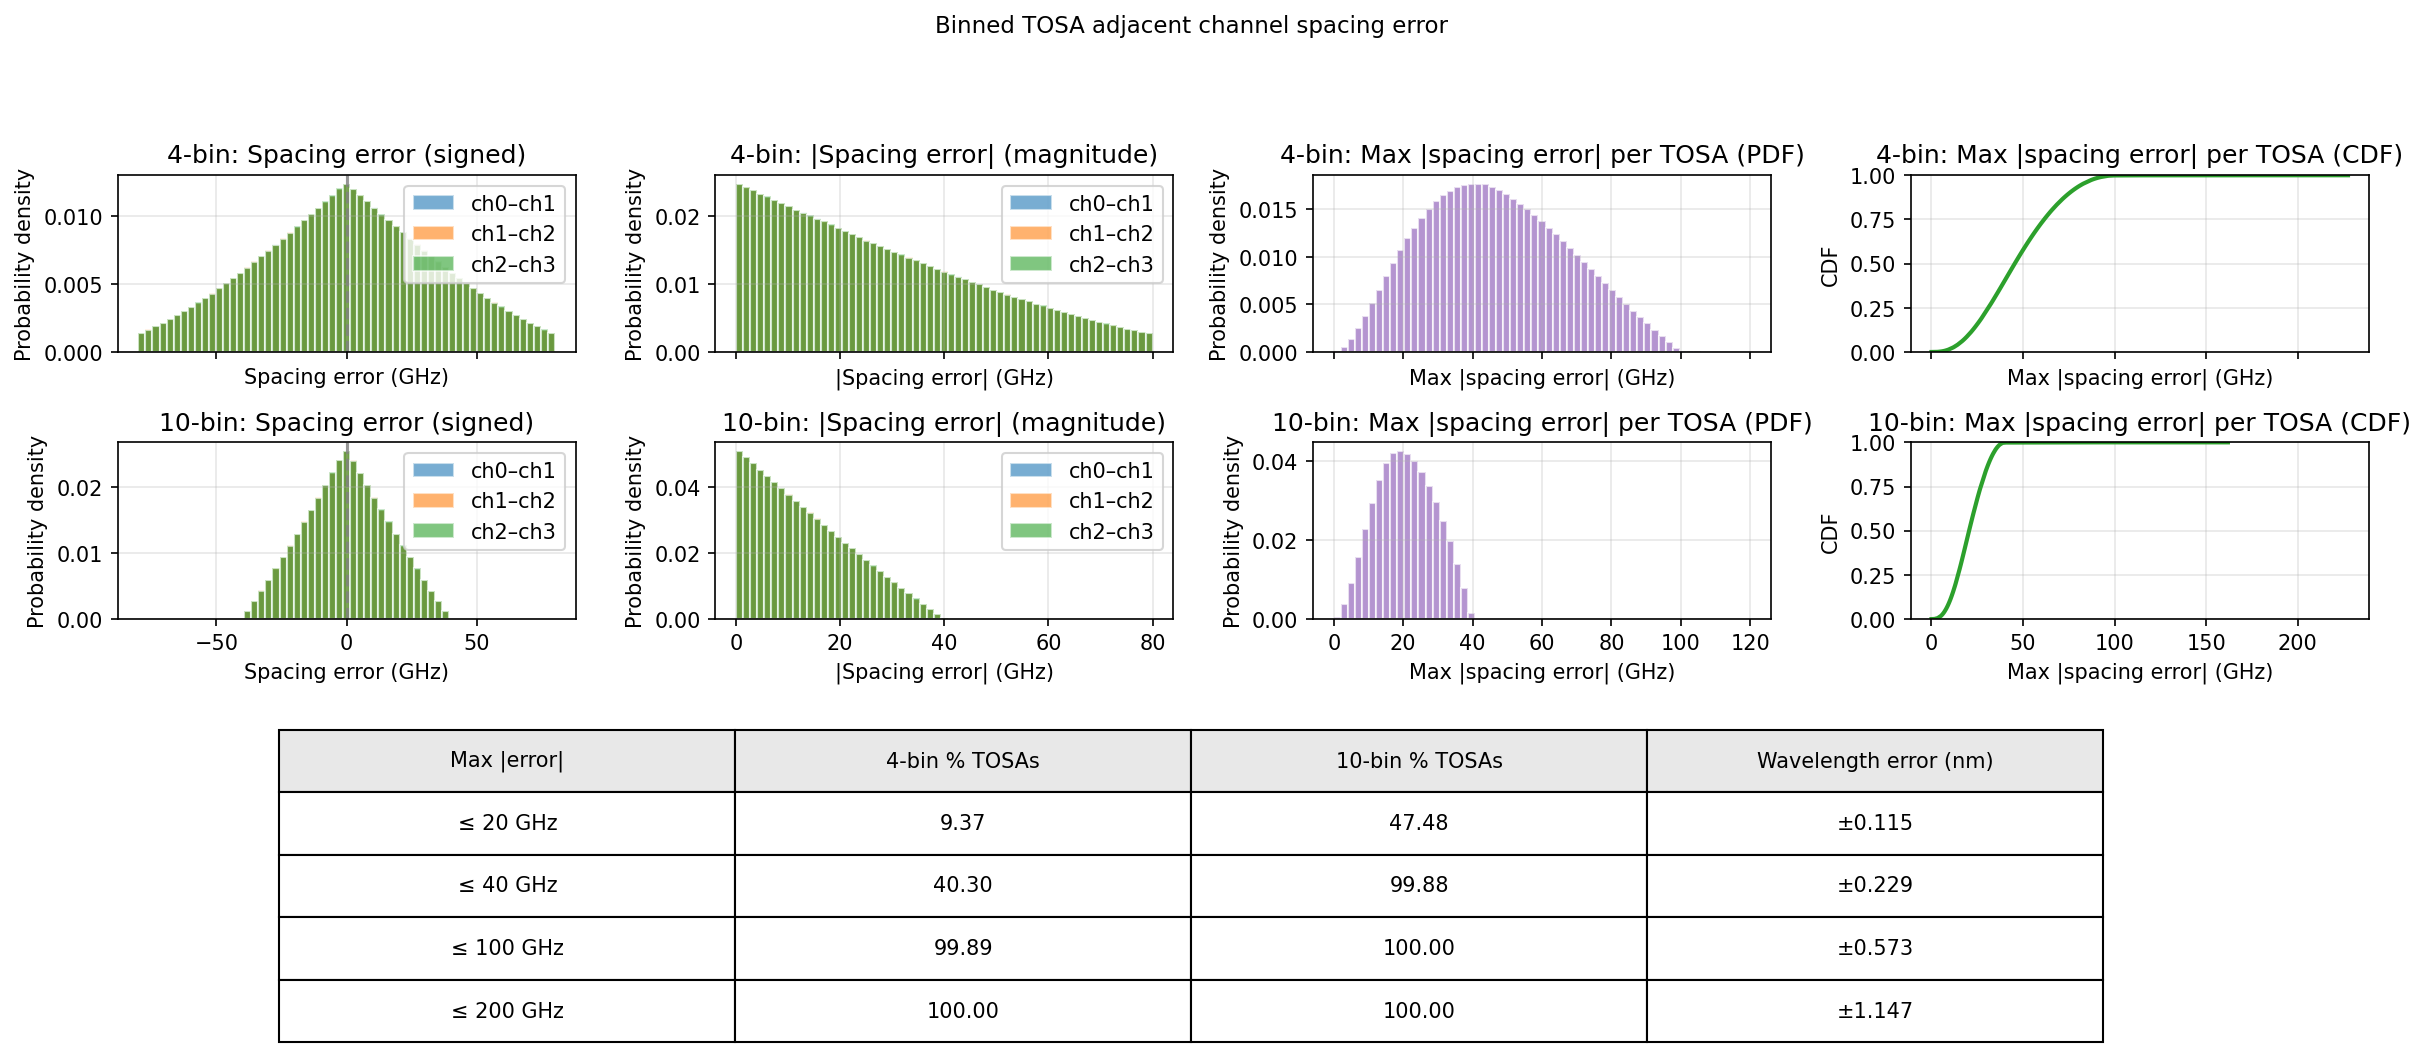

In [5]:
from IPython.display import Image, display
display(Image(filename="binned_sampling_tosa_spacing_error_histograms.png", width=800))

---

## 4. Which Strategy Gives Maximum Yield for ≤ 40 GHz?

- **Random:** **6.87%** of TOSAs have max |spacing error| ≤ 40 GHz.  
- **4-bin binned:** **40.30%** — much better than random.  
- **10-bin binned:** **99.88%** — almost all TOSAs meet the 40 GHz spec.

**Conclusion:** **The 10-bin binned strategy gives the best yield for ≤ 40 GHz |error|** in this setup. By grouping lasers into narrow deviation bins and assembling TOSAs from the same bin index (full inventory, no per-bin cap), adjacent channel spacing errors are greatly reduced, and the 10-bin scheme (40 GHz bin width) aligns well with the 40 GHz error target.

---
## 5. 8-Channel TOSA (200 GHz spacing)

The same process is repeated for an **8-channel TOSA** with **all adjacent channels spaced by 200 GHz**. Channel centers (frequency deviation from 1311 nm ref) are **0, 200, 400, 600, 800, 1000, 1200, 1400 GHz** (ch0–ch7). There are **7 adjacent spacing pairs**; each has nominal spacing **200 GHz**. Max |error| per TOSA is the maximum of the 7 absolute spacing errors. Same laser statistics and same strategies: random sampling, 4-bin binned, 10-bin binned (full inventory). Scripts: `random_sampling_tosa_8ch.py`, `binned_sampling_tosa_8ch.py`.

In [6]:
# Run 8-channel analyses and generate yield table + figures
import numpy as np
import random_sampling_tosa_8ch as r8
import binned_sampling_tosa_8ch as b8

rng = np.random.default_rng(42)
tosas_8ch = r8.build_tosas_for_class(r8.CHANNELS_8CH_200GHZ, r8.N_TOSAS, rng=rng)
err_r8 = np.diff(tosas_8ch, axis=1) - r8.NOMINAL_SPACING_8CH
max_r8 = np.max(np.abs(err_r8), axis=1)
n_r8 = len(max_r8)

e10_8, e4_8 = b8.run_binned_sampling_8ch(rng)
max_4_8 = np.max(np.abs(e4_8), axis=1)
max_10_8 = np.max(np.abs(e10_8), axis=1)
n_4_8, n_10_8 = len(max_4_8), len(max_10_8)

thresholds = [20, 40, 100, 200]
pct_r8 = [100 * np.sum(max_r8 <= t) / n_r8 for t in thresholds]
pct_4_8 = [100 * np.sum(max_4_8 <= t) / n_4_8 for t in thresholds]
pct_10_8 = [100 * np.sum(max_10_8 <= t) / n_10_8 for t in thresholds]
wl_nm = [r8.ghz_to_wavelength_error_nm(t) for t in thresholds]

print("8-channel yield (seed 42)")
print("Max |error|     | Random (%) | 4-bin (%) | 10-bin (%) | Wavelength (nm)")
print("-" * 72)
for t, pr, p4, p10, w in zip(thresholds, pct_r8, pct_4_8, pct_10_8, wl_nm):
    print(f"  ≤ {t:3} GHz     | {pr:9.2f} | {p4:8.2f} | {p10:9.2f} | ±{w:.3f}")
print(f"\nTOSA counts: Random {n_r8:,}  |  4-bin {n_4_8:,}  |  10-bin {n_10_8:,}")

r8.plot_adjacent_spacing_error_histograms(tosas_8ch, out_path="random_sampling_tosa_8ch_adjacent_spacing_error_histograms.png")
b8.plot_binned_spacing_error_histograms(e10_8, e4_8, out_path="binned_sampling_tosa_8ch_spacing_error_histograms.png")

8-channel yield (seed 42)
Max |error|     | Random (%) | 4-bin (%) | 10-bin (%) | Wavelength (nm)
------------------------------------------------------------------------
  ≤  20 GHz     |      0.00 |     0.74 |     18.55 | ±0.115
  ≤  40 GHz     |      0.27 |    13.85 |     99.77 | ±0.229
  ≤ 100 GHz     |     22.66 |    99.77 |    100.00 | ±0.573
  ≤ 200 GHz     |     90.79 |   100.00 |    100.00 | ±1.147

TOSA counts: Random 10,000,000  |  4-bin 9,994,194  |  10-bin 9,989,720
Saved random_sampling_tosa_8ch_adjacent_spacing_error_histograms.png
Saved binned_sampling_tosa_8ch_spacing_error_histograms.png


**8-channel random sampling — adjacent spacing error histograms and yield table:**

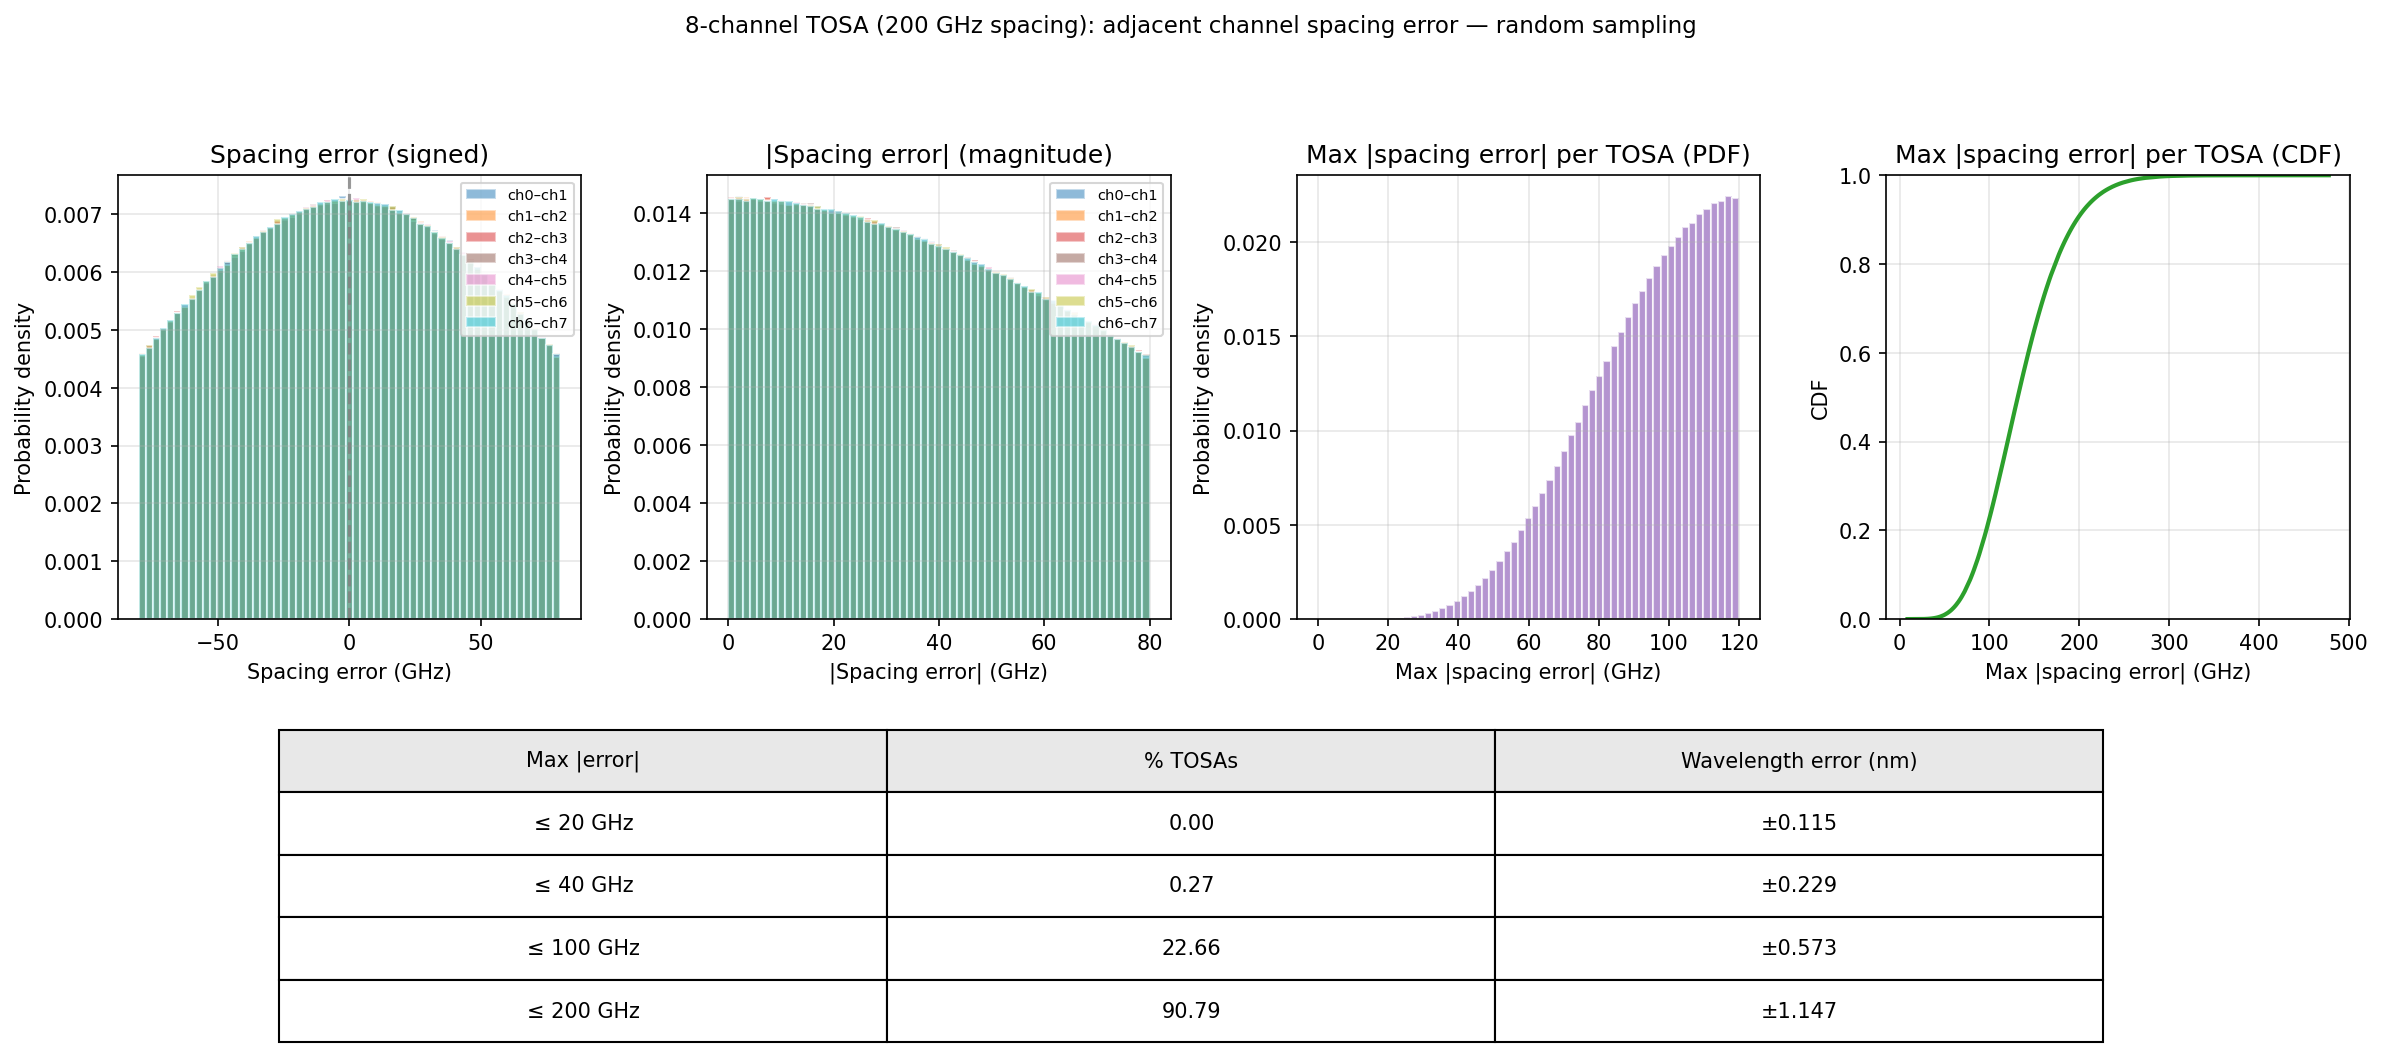

In [7]:
from IPython.display import Image, display
display(Image(filename="random_sampling_tosa_8ch_adjacent_spacing_error_histograms.png", width=800))

**8-channel binned sampling (4-bin and 10-bin) — adjacent spacing error histograms and yield table:**

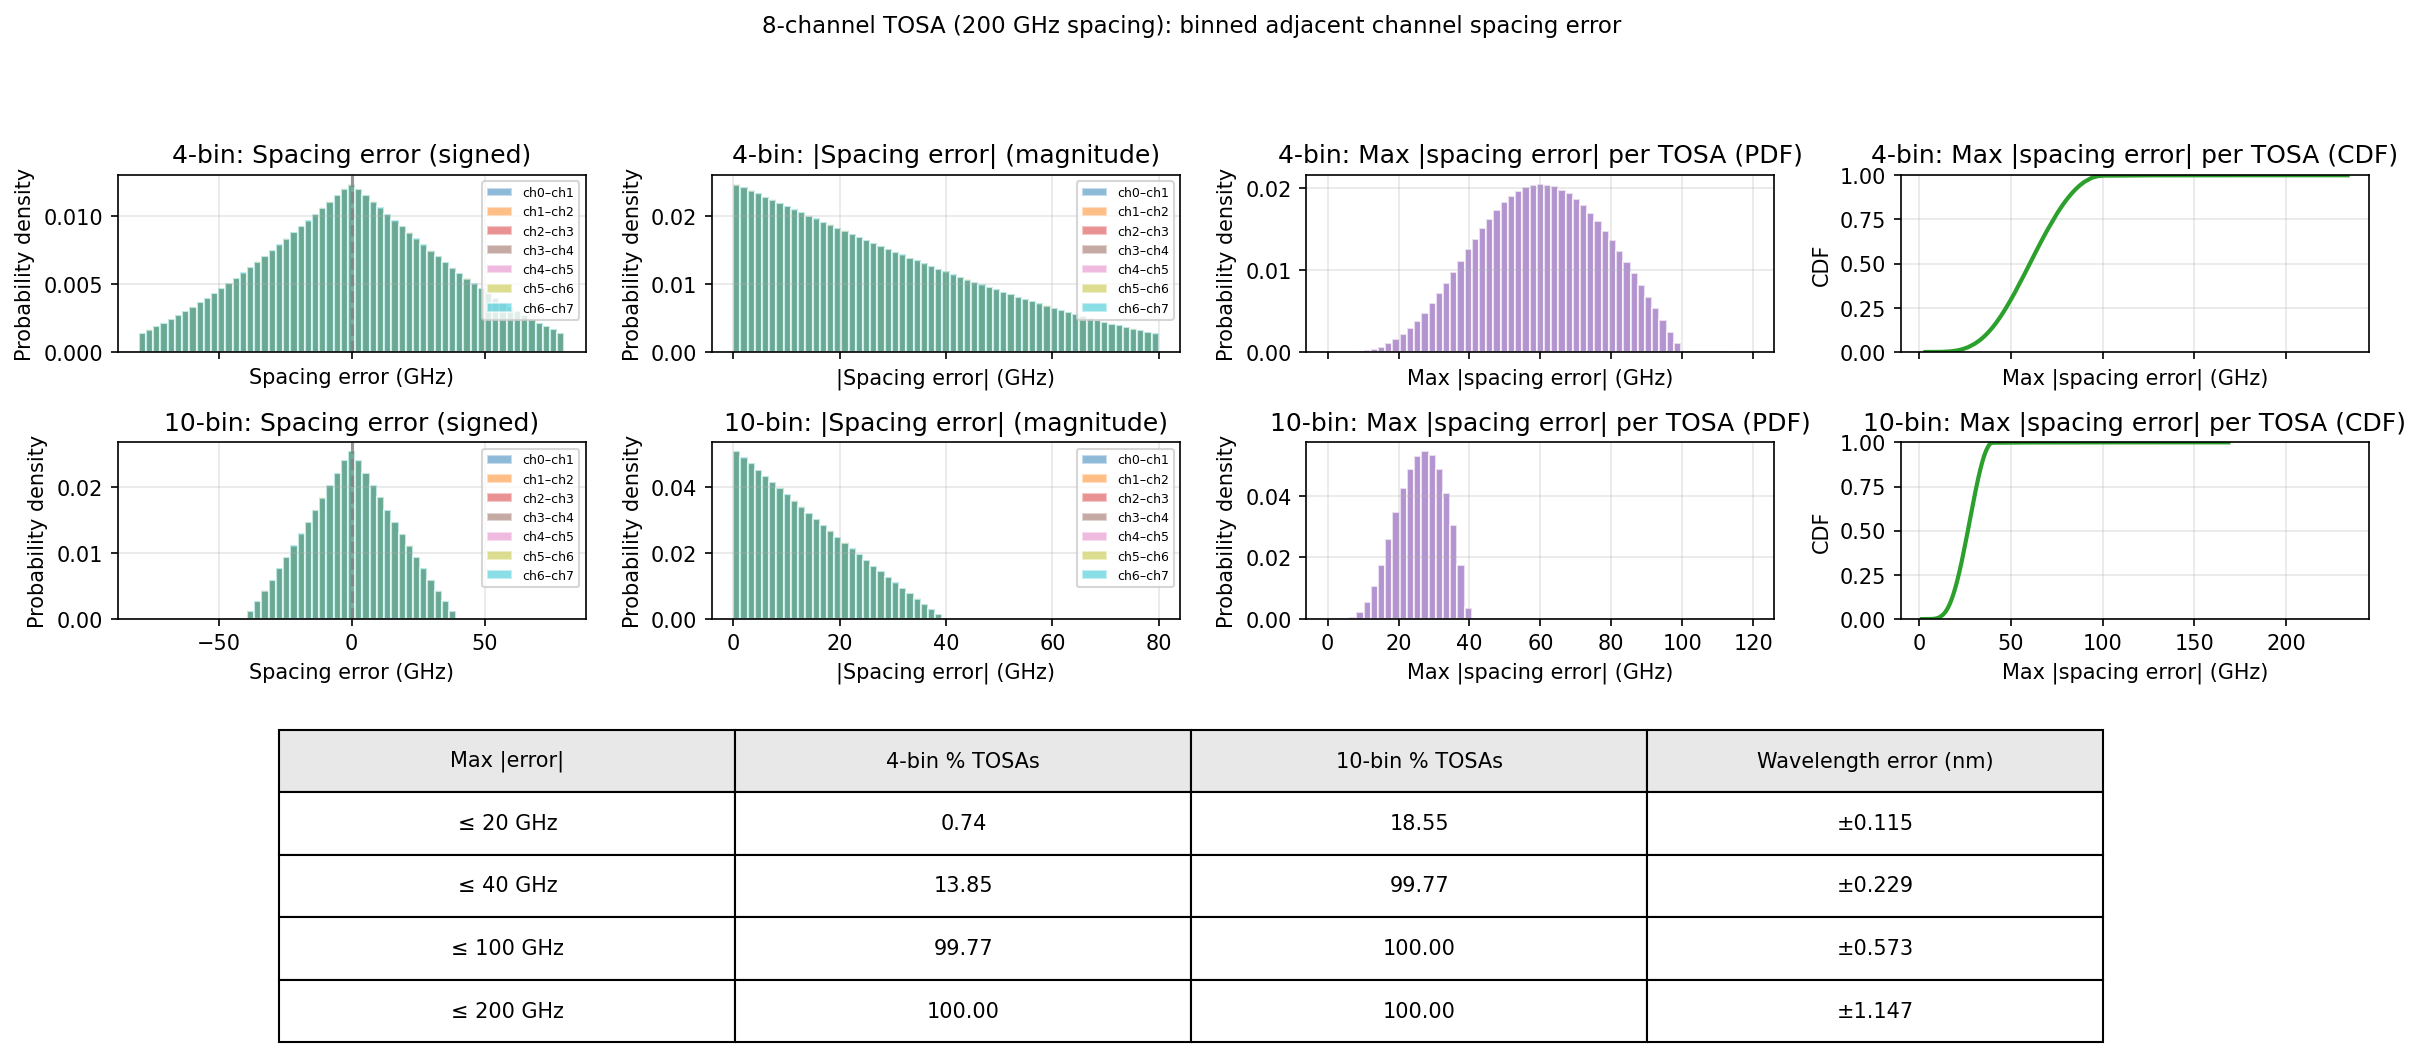

In [8]:
from IPython.display import Image, display
display(Image(filename="binned_sampling_tosa_8ch_spacing_error_histograms.png", width=800))

With 7 adjacent pairs (vs 3 for 4-channel), **random yield at ≤ 40 GHz drops sharply** (e.g. &lt;1%). **10-bin binned again gives the best yield** (~99.77% at ≤ 40 GHz); 4-bin is much better than random but below 10-bin.